1. SETUP

In [1]:
# =========================================================
# Librerías base
# =========================================================
import os
import sys
import importlib
import time
import joblib

# Manejo de datos
import pandas as pd
import numpy as np

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Pesos de clase para desbalance
from sklearn.utils.class_weight import compute_class_weight

# ---------------------------------------------------------
# Detecta la raíz del proyecto
# ---------------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------------
# Agrega la raíz al path para importar módulos propios
# ---------------------------------------------------------
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ---------------------------------------------------------
# Importa configuración del proyecto
# ---------------------------------------------------------
import utils.config as config
importlib.reload(config)

# ---------------------------------------------------------
# Importa servicio de entrenamiento reutilizable
# ---------------------------------------------------------
from services.training.training_service import TrainingService

print("FULL_ARTIFACTS_DIR:", config.FULL_ARTIFACTS_DIR)

FULL_ARTIFACTS_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full


2. Cargar artefactos del preprocessing full

In [2]:
# ---------------------------------------------------------
# Carga los datasets multiclase del flujo full
# generados en 02_preprocessing_full.ipynb
# ---------------------------------------------------------
X_train = pd.read_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_train_full_multiclass.parquet")
)

X_test = pd.read_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_test_full_multiclass.parquet")
)

y_train = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_train_full_multiclass.csv")
).squeeze("columns")

y_test = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_test_full_multiclass.csv")
).squeeze("columns")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17871216, 22)
X_test: (4467805, 22)
y_train: (17871216,)
y_test: (4467805,)


3. Inspección del desbalance en train

In [3]:
# ---------------------------------------------------------
# Muestra cómo están distribuidas las clases en entrenamiento
# Esto es importante para entender el desbalance real
# ---------------------------------------------------------
class_distribution = pd.Series(y_train).value_counts().sort_index()

print("Distribución de clases en y_train:")
print(class_distribution)

Distribución de clases en y_train:
type
backdoor       406493
ddos          4932006
dos           2700262
injection      362127
mitm              842
normal         637104
password      1374854
ransomware      58244
scanning      5712129
xss           1687155
Name: count, dtype: int64


4. Calcular pesos de clase

In [4]:
# ---------------------------------------------------------
# Calcula pesos automáticos por clase.
# Esto ayuda especialmente a Random Forest y DNN.
# En clases poco frecuentes, el peso será más alto.
# ---------------------------------------------------------
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_dict = dict(zip(classes, class_weights_array))

print("Pesos de clase:")
print(class_weights_dict)

from sklearn.preprocessing import LabelEncoder
import joblib
import os

# ---------------------------------------------------------
# Codificar y_train e y_test a enteros para XGBoost
# ---------------------------------------------------------
target_encoder = LabelEncoder()

y_train_enc = target_encoder.fit_transform(y_train.astype(str))
y_test_enc = target_encoder.transform(y_test.astype(str))

# Guardar encoder para reutilizarlo después
joblib.dump(
    target_encoder,
    os.path.join(config.FULL_ARTIFACTS_DIR, "target_encoder_full_multiclass.pkl")
)

print("Clases codificadas:")
print(list(target_encoder.classes_))
print("Valores únicos y_train_enc:", np.unique(y_train_enc))

# ---------------------------------------------------------
# Crear pesos por muestra para XGBoost multiclase
# ---------------------------------------------------------
sample_weight = pd.Series(y_train).map(class_weights_dict).values

print("Primeros sample weights:")
print(sample_weight[:10])

Pesos de clase:
{'backdoor': np.float64(4.396438807064328), 'ddos': np.float64(0.36235187061816226), 'dos': np.float64(0.661832666607907), 'injection': np.float64(4.935068636141464), 'mitm': np.float64(2122.4722090261284), 'normal': np.float64(2.805070443758005), 'password': np.float64(1.2998628217978054), 'ransomware': np.float64(30.683359659364054), 'scanning': np.float64(0.3128643628321419), 'xss': np.float64(1.0592515803230882)}
Clases codificadas:
['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Valores únicos y_train_enc: [0 1 2 3 4 5 6 7 8 9]
Primeros sample weights:
[0.31286436 0.31286436 0.66183267 1.29986282 0.36235187 0.66183267
 0.36235187 0.31286436 0.31286436 0.31286436]


5. Crear instancia del servicio de training

In [5]:
# ---------------------------------------------------------
# Instancia del servicio de entrenamiento
# ---------------------------------------------------------
trainer = TrainingService()

# ---------------------------------------------------------
# Número de clases para multiclase
# ---------------------------------------------------------
num_classes = len(np.unique(y_train))
print("Número de clases:", num_classes)

Número de clases: 10


6. Entrenar Random Forest

In [6]:
# ---------------------------------------------------------
# Entrenamiento de Random Forest
# Se usa class_weight='balanced' para mitigar desbalance
# ---------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

rf_start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=config.RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_elapsed = time.time() - rf_start
print(f"✔ Random Forest entrenado en {rf_elapsed:.2f} seg")

✔ Random Forest entrenado en 2188.87 seg


7. Entrenar XGBoost

In [7]:
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Codificación de etiquetas para XGBoost
# ---------------------------------------------------------
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
num_classes = len(label_encoder.classes_)

print("✔ Clases originales:", list(label_encoder.classes_))
print("✔ Clases codificadas:", sorted(set(y_train_encoded)))
print("✔ Número de clases:", num_classes)

from xgboost import XGBClassifier

xgb_start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=config.RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_enc, sample_weight=sample_weight)

xgb_elapsed = time.time() - xgb_start
print(f"✔ XGBoost multiclase balanceado entrenado en {xgb_elapsed:.2f} seg")

✔ Clases originales: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
✔ Clases codificadas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
✔ Número de clases: 10
✔ XGBoost multiclase balanceado entrenado en 622.04 seg


8. Entrenar LightGBM

In [8]:
# ---------------------------------------------------------
# Entrenamiento de LightGBM
# Primera versión base para full dataset
# ---------------------------------------------------------
from lightgbm import LGBMClassifier

lgb_start = time.time()

lgb_model = LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,
    n_estimators=100,
    learning_rate=0.1,
    random_state=config.RANDOM_STATE,
    class_weight="balanced"
)

lgb_model.fit(X_train, y_train_enc)

lgb_elapsed = time.time() - lgb_start
print(f"✔ LightGBM multiclase balanceado entrenado en {lgb_elapsed:.2f} seg")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.906767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1914
[LightGBM] [Info] Number of data points in the train set: 17871216, number of used features: 22
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
✔ LightGBM multiclase balanceado entrenado en 515.04 seg


9. Función de evaluación

In [9]:
# ---------------------------------------------------------
# Función para evaluar un modelo multiclase
# Calcula:
# - accuracy
# - precision weighted
# - recall weighted
# - F1 weighted
# - F1 macro
# ---------------------------------------------------------
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

def evaluate_model(model, X_test, y_test, model_name, y_pred_override=None):
    print(f"\n==================== {model_name} ====================\n")

    if y_pred_override is not None:
        y_pred = y_pred_override
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    print(classification_report(y_test, y_pred, zero_division=0))

    results = {
        "model": model_name,
        "accuracy": acc,
        "precision_weighted": precision_w,
        "recall_weighted": recall_w,
        "f1_weighted": f1_w,
        "precision_macro": precision_m,
        "recall_macro": recall_m,
        "f1_macro": f1_m
    }

    return results, y_pred

10. Evaluar Random Forest

In [10]:
rf_results, rf_pred = evaluate_model(
    model=rf_model,
    X_test=X_test,
    y_test=y_test,
    model_name="Random Forest Full"
)


==================== Random Forest Full ====================

              precision    recall  f1-score   support

    backdoor       0.54      0.97      0.69    101623
        ddos       1.00      0.96      0.98   1233002
         dos       0.96      1.00      0.98    675066
   injection       0.97      0.96      0.97     90532
        mitm       0.54      0.56      0.55       210
      normal       0.99      0.90      0.94    159276
    password       0.96      0.99      0.97    343714
  ransomware       0.13      0.95      0.22     14561
    scanning       1.00      0.89      0.94   1428032
         xss       0.99      0.99      0.99    421789

    accuracy                           0.95   4467805
   macro avg       0.81      0.92      0.82   4467805
weighted avg       0.97      0.95      0.96   4467805



11. Evaluar XGBoost

In [11]:
y_pred_encoded = xgb_model.predict(X_test).astype(int)

xgb_results, xgb_pred = evaluate_model(
    model=None,
    X_test=None,
    y_test=y_test_enc,
    model_name="XGBoost Full Balanced",
    y_pred_override=y_pred_encoded
)


==================== XGBoost Full Balanced ====================

              precision    recall  f1-score   support

           0       0.48      1.00      0.65    101623
           1       1.00      0.95      0.98   1233002
           2       0.96      1.00      0.98    675066
           3       0.93      0.96      0.95     90532
           4       0.05      0.95      0.10       210
           5       0.98      0.87      0.92    159276
           6       0.95      1.00      0.97    343714
           7       0.12      0.95      0.21     14561
           8       1.00      0.87      0.93   1428032
           9       0.99      0.99      0.99    421789

    accuracy                           0.94   4467805
   macro avg       0.75      0.95      0.77   4467805
weighted avg       0.97      0.94      0.95   4467805



12. Evaluar LigthGBM

In [12]:
lgb_results, lgb_pred = evaluate_model(
    model=lgb_model,
    X_test=X_test,
    y_test=y_test_enc,
    model_name="LightGBM Full"
)


==================== LightGBM Full ====================

              precision    recall  f1-score   support

           0       0.50      0.99      0.66    101623
           1       1.00      0.96      0.98   1233002
           2       0.96      1.00      0.98    675066
           3       0.95      0.97      0.96     90532
           4       0.09      0.91      0.16       210
           5       0.99      0.88      0.93    159276
           6       0.95      1.00      0.97    343714
           7       0.12      0.95      0.22     14561
           8       1.00      0.88      0.94   1428032
           9       0.99      0.99      0.99    421789

    accuracy                           0.94   4467805
   macro avg       0.75      0.95      0.78   4467805
weighted avg       0.97      0.94      0.95   4467805



13. Tabla comparativa

In [13]:
# ---------------------------------------------------------
# Consolida resultados en una tabla comparativa
# ---------------------------------------------------------
results_df = pd.DataFrame([rf_results, xgb_results, lgb_results])

# Ordenar por F1 weighted de mayor a menor
results_df = results_df.sort_values(by="f1_weighted", ascending=False).reset_index(drop=True)

results_df

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Random Forest Full,0.947053,0.973984,0.947053,0.956986,0.807870,0.916930,0.824290
1,LightGBM Full,0.942246,0.973408,0.942246,0.953412,0.754607,0.951583,0.778039
2,XGBoost Full Balanced,0.938730,0.972070,0.938730,0.950576,0.746761,0.952800,0.767743


14. Guardar resultados

In [14]:
# ---------------------------------------------------------
# Guarda la tabla de resultados del flujo full
# ---------------------------------------------------------
results_path = os.path.join(config.FULL_ARTIFACTS_DIR, "multiclass_model_results_full.csv")
results_df.to_csv(results_path, index=False)

print("Resultados full guardados en:")
print(results_path)

Resultados full guardados en:
/home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full/multiclass_model_results_full.csv


15. Guardar modelos entrenados

In [15]:
# ---------------------------------------------------------
# Guarda los modelos entrenados del flujo full
# ---------------------------------------------------------
joblib.dump(
    rf_model,
    os.path.join(config.FULL_ARTIFACTS_DIR, "rf_multiclass_full.pkl")
)

joblib.dump(
    xgb_model,
    os.path.join(config.FULL_ARTIFACTS_DIR, "xgb_multiclass_full.pkl")
)

joblib.dump(
    lgb_model,
    os.path.join(config.FULL_ARTIFACTS_DIR, "lgb_multiclass_full.pkl")
)

print("Modelos full guardados correctamente.")

Modelos full guardados correctamente.


16. Guardar predicciones

In [16]:
# ---------------------------------------------------------
# Guarda predicciones del test set para análisis posterior
# ---------------------------------------------------------
pd.DataFrame({"y_true": y_test, "y_pred": rf_pred}).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "rf_predictions_full.csv"),
    index=False
)

pd.DataFrame({"y_true": y_test_enc, "y_pred": xgb_pred}).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "xgb_predictions_full.csv"),
    index=False
)

pd.DataFrame({"y_true": y_test_enc, "y_pred": lgb_pred}).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "lgb_predictions_full.csv"),
    index=False
)

print("Predicciones guardadas.")

Predicciones guardadas.


17. Matrices de confusión

In [17]:
# ---------------------------------------------------------
# Función para graficar matrices de confusión
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

In [18]:
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# cargar dataset consolidado full
df_full = pd.read_parquet(config.FULL_CONSOLIDATED_PATH)

# reconstruir encoder del target multiclase
target_encoder = LabelEncoder()
target_encoder.fit(df_full["type"].astype(str))

class_names = list(target_encoder.classes_)
print(class_names)

['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


In [19]:
def plot_confusion(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 9))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

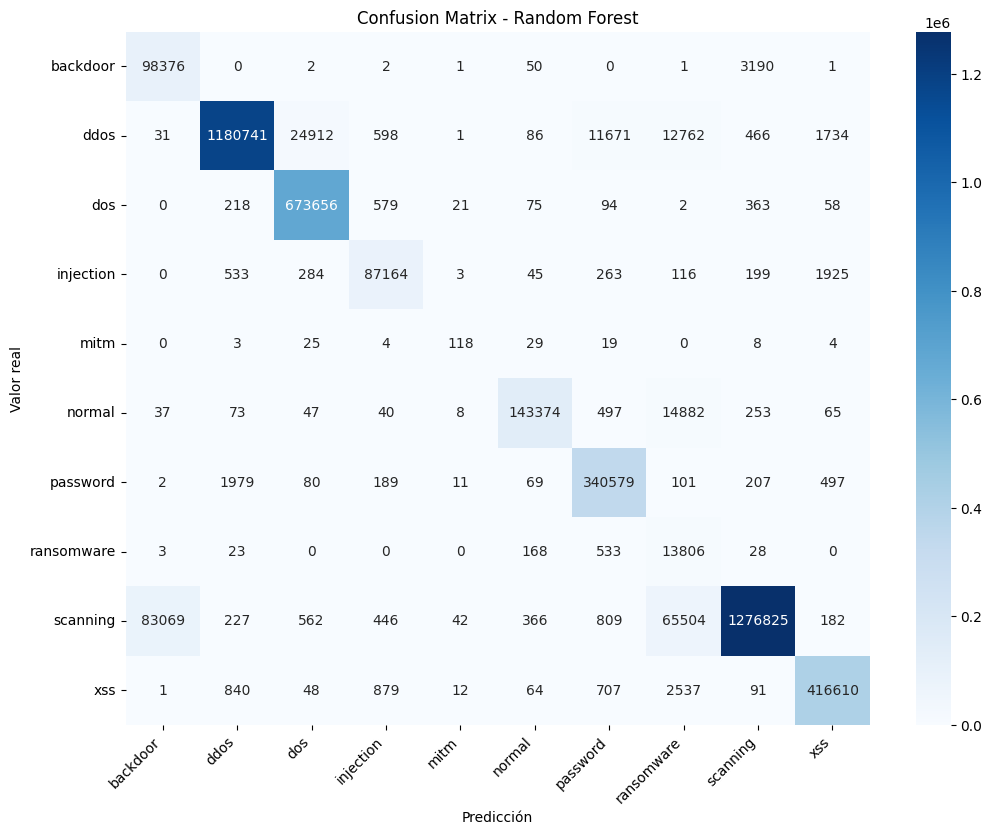

In [20]:
plot_confusion(y_test, rf_pred, "Confusion Matrix - Random Forest", class_names)

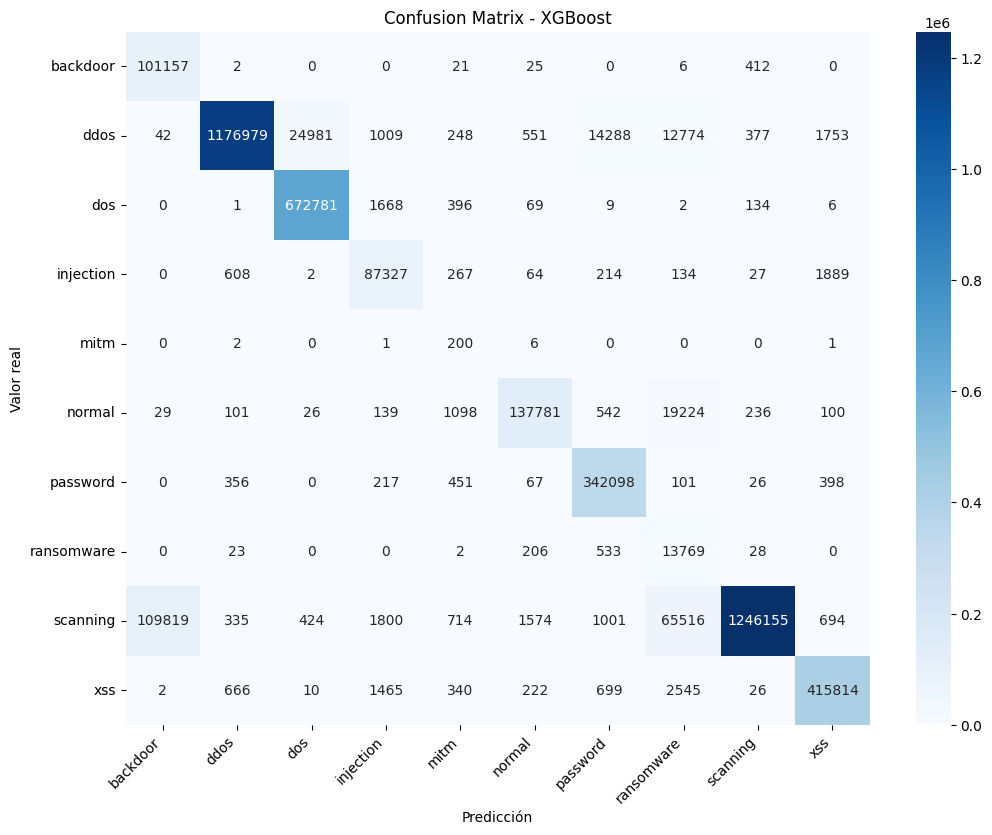

In [21]:
plot_confusion(
    y_test_enc,
    y_pred_encoded,
    "Confusion Matrix - XGBoost",
    class_names
)

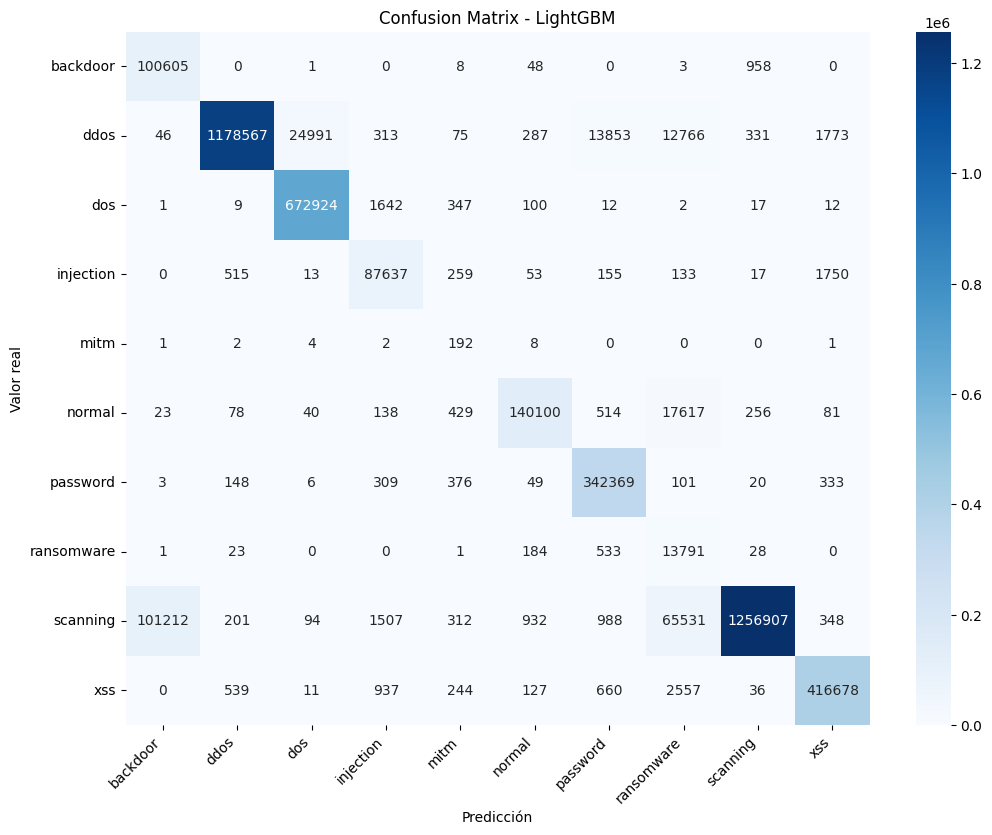

In [22]:
plot_confusion(
    y_test_enc,
    lgb_pred,
    "Confusion Matrix - LightGBM",
    class_names
)

18. Identificar mejor modelo

In [23]:
# ---------------------------------------------------------
# Identifica el mejor modelo según F1 weighted
# ---------------------------------------------------------
best_model = results_df.iloc[0]

print("Mejor modelo del flujo full:")
print(best_model)

Mejor modelo del flujo full:
model                 Random Forest Full
accuracy                        0.947053
precision_weighted              0.973984
recall_weighted                 0.947053
f1_weighted                     0.956986
precision_macro                  0.80787
recall_macro                     0.91693
f1_macro                         0.82429
Name: 0, dtype: object
